In [1]:
import pandas as pd

df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')
print(df_Lung_Cancer)

df_Lung_Cancer_Prediction_Dataset = pd.read_csv('Lung Cancer Prediction Dataset.csv')
print(df_Lung_Cancer_Prediction_Dataset)

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')
print(df_Lung_Cancer_Risk_Dataset)

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  \
0                  1         2         1         2                  2   
1                  2         2       

DATASET 1: Lung Cancer Dataset
First 5 rows
   GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0       1   69        1               2        2              1   
1       1   74        2               1        1              1   
2       0   59        1               1        1              2   
3       1   63        2               2        2              1   
4       0   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN  LUNG_CANCER  
0    

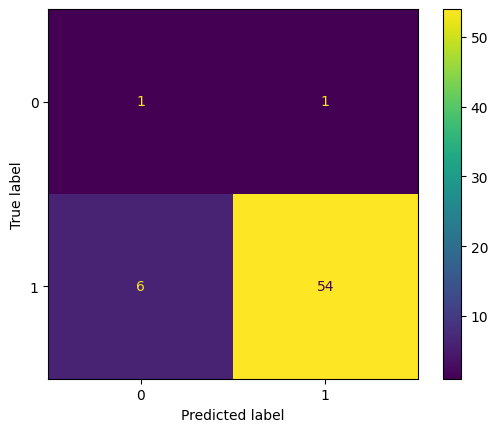


Logistic Regression Results : Dataset 1 (5-fold CV Baseline - All features)
Mean Accuracy : 0.8643
Mean Precision: 0.9670
Mean F1-score : 0.9181


In [5]:
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#Dataset 1
print("DATASET 1: Lung Cancer Dataset")

pd.set_option('display.max_columns', None)

#df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')

df_Lung_Cancer['GENDER'] = LabelEncoder().fit_transform(df_Lung_Cancer['GENDER'])
df_Lung_Cancer['LUNG_CANCER'] = LabelEncoder().fit_transform(df_Lung_Cancer['LUNG_CANCER'])

df_Lung_Cancer.columns = df_Lung_Cancer.columns.str.strip()

print("First 5 rows")
print(df_Lung_Cancer.head())

print("\nColumn names:")
print(df_Lung_Cancer.columns.tolist())

print("\nDataset info:")
df_Lung_Cancer.info()

print("\nMissing values:")
print(df_Lung_Cancer.isnull().sum())

for col in df_Lung_Cancer.columns:
    if df_Lung_Cancer[col].dtype == "object":
        df_Lung_Cancer[col] = df_Lung_Cancer[col].fillna(df_Lung_Cancer[col].mode()[0])
    else:
        df_Lung_Cancer[col] = df_Lung_Cancer[col].fillna(df_Lung_Cancer[col].median())

print("\nMissing values after filling:")
print(df_Lung_Cancer.isnull().sum())

X1 = df_Lung_Cancer.drop(columns=['LUNG_CANCER'])
y1 = df_Lung_Cancer['LUNG_CANCER']

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)



# Logistic Regression model
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X1_scaled, y1, test_size=0.2, random_state=42) #https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/

model.fit(X_train, y_train)

print(classification_report(y_test,model.predict(X_test)))


# Predictions
y_pred1 = model.predict(X_test)

#Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")
print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")
print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")
print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_)
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy" : "accuracy",
    "precision" : "precision",
    "recall" : "recall",
    "f1" : "f1"
}

baseline_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1_scaled,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nLogistic Regression Results : Dataset 1 (5-fold CV Baseline - All features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")




In [ ]:
print("DATASET 2: Lung Cancer Prediction Dataset")

df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'] = LabelEncoder().fit_transform(df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'])

for col in df_Lung_Cancer_Prediction_Dataset.columns:
  if df_Lung_Cancer_Prediction_Dataset[col].dtype == 'object':
    df_Lung_Cancer_Prediction_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Prediction_Dataset[col])

# Prepare features and target
X2 = df_Lung_Cancer_Prediction_Dataset.drop(columns=['PULMONARY_DISEASE'])
y2 = df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE']

# Scale features
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Split data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42)

# Logistic Regression model
model2 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model2.fit(X_train2, y_train2)

# Predictions
y_pred2 = model2.predict(X_test2)

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test2, y_pred2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))

print(f"\nAccuracy: {accuracy_score(y_test2, y_pred2):.4f}")

print(f"F1-Score: {f1_score(y_test2, y_pred2):.4f}")


DATASET 2: Lung Cancer Prediction Dataset

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       571
           1       0.81      0.93      0.86       429

    accuracy                           0.88      1000
   macro avg       0.87      0.88      0.87      1000
weighted avg       0.88      0.88      0.88      1000


Confusion Matrix:
[[476  95]
 [ 30 399]]

Accuracy: 0.8750
F1-Score: 0.8646


In [ ]:
print ("DATASET 3: Lung Cancer Risk Dataset")

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')

# Encode all columns
for col in df_Lung_Cancer_Risk_Dataset.columns:
    df_Lung_Cancer_Risk_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Risk_Dataset[col])

X3 = df_Lung_Cancer_Risk_Dataset.drop(columns=['lung_cancer'])
y3 = df_Lung_Cancer_Risk_Dataset['lung_cancer']

# Scale features
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3_scaled, y3, test_size=0.2, random_state=42)

model3= LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

print("\nClassification Report:")
print(classification_report(y_test3, y_pred3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test3, y_pred3))

print(f"\nAccuracy: {accuracy_score(y_test3, y_pred3):.4f}")

print(f"F1-Score: {f1_score(y_test3, y_pred3):.4f}")


DATASET 3: Lung Cancer Risk Dataset

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.67      0.56      3118
           1       0.82      0.67      0.73      6882

    accuracy                           0.67     10000
   macro avg       0.65      0.67      0.65     10000
weighted avg       0.71      0.67      0.68     10000


Confusion Matrix:
[[2104 1014]
 [2300 4582]]

Accuracy: 0.6686
F1-Score: 0.7344
